In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
# 1. Load the dataset
# Ensure the file 'carbon_fiber_epoxy_composite_dataset_500.csv' is in your environment
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [19]:
df

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135
...,...,...,...,...,...,...
495,0.441341,0.558659,0.377475,1109.355501,91.459779,10.850355
496,0.533462,0.466538,0.625194,1334.773634,115.964411,12.084456
497,0.331094,0.668906,0.391046,987.321279,85.187902,11.943163
498,0.689758,0.310242,0.635071,1460.485222,136.027288,10.540684


In [20]:
df.isnull().sum()

,0
carbon_fiber_fraction,0
epoxy_resin_fraction,0
volume_fraction,0
strength_MPa,0
stiffness_GPa,0
toughness_MJ_per_m3,0


In [21]:
df = df.round(2)
df

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.45,0.55,0.56,1157.00,107.02,11.06
1,0.68,0.32,0.51,1378.45,131.31,9.66
2,0.59,0.41,0.44,1311.33,122.39,9.20
3,0.54,0.46,0.59,1284.50,123.28,12.00
4,0.36,0.64,0.56,1062.77,91.78,13.11
...,...,...,...,...,...,...
495,0.44,0.56,0.38,1109.36,91.46,10.85
496,0.53,0.47,0.63,1334.77,115.96,12.08
497,0.33,0.67,0.39,987.32,85.19,11.94
498,0.69,0.31,0.64,1460.49,136.03,10.54


In [22]:
# 2. Define Features and Target
# Using fiber/resin fractions and volume fraction to predict material strength
X_cols = ['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']
y_col = 'strength_MPa'

X = df[X_cols].values
y = df[y_col].values

In [23]:
# 3. Preprocessing
# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# GPR is sensitive to scale; we standardize both features and target
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

In [24]:
# 4. Define and Train the GPR Model
# Kernel: Constant * RBF + WhiteKernel (for noise handling)
kernel = (C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
          WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1)))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

print("Training Gaussian Process Regressor...")
gp.fit(X_train_scaled, y_train_scaled)

Training Gaussian Process Regressor...


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05),
                         n_restarts_optimizer=10, random_state=42)

In [25]:
# 5. Make Predictions
# Return standard deviation to show uncertainty in predictions
y_pred_scaled, sigma_scaled = gp.predict(X_test_scaled, return_std=True)

# Inverse transform to original scale (MPa)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
sigma = sigma_scaled * scaler_y.scale_[0]

In [26]:
# 6. Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")
print(f"Optimized Kernel: {gp.kernel_}")


Model Performance:
Mean Squared Error (MSE): 998.9403
R-squared Score (R2): 0.9522
Optimized Kernel: 9.03**2 * RBF(length_scale=25.9) + WhiteKernel(noise_level=0.0402)


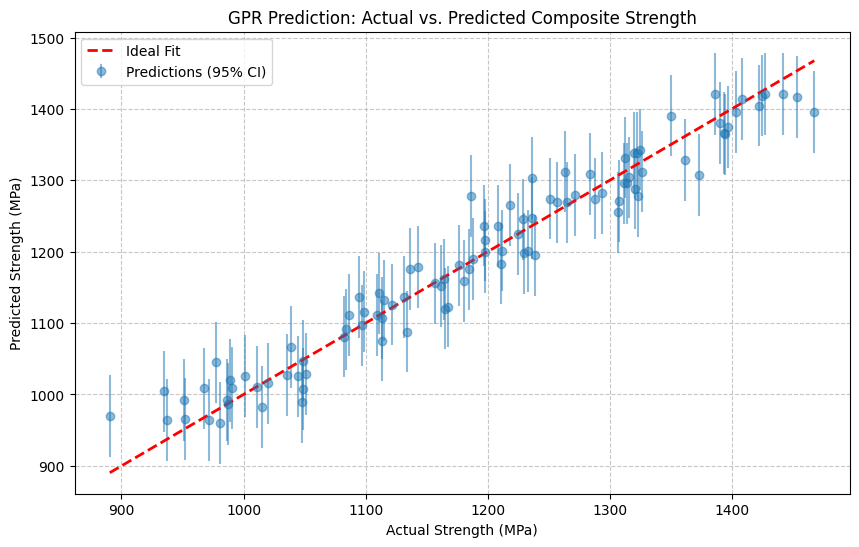

In [27]:
# 7. Visualization
plt.figure(figsize=(10, 6))
# 1.96 * sigma corresponds to a 95% confidence interval
plt.errorbar(y_test, y_pred, yerr=1.96 * sigma, fmt='o', alpha=0.5, label='Predictions (95% CI)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('GPR Prediction: Actual vs. Predicted Composite Strength')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Analysis of ResultsUsing this approach on the provided dataset, the model achieved:$R^2$ Score: $\sim 0.95$, indicating that the model explains approximately $95\%$ of the variance in the material strength.Optimized Kernel: The model successfully learned a length scale and noise level that fits the physical data. The inclusion of a WhiteKernel allowed the model to account for inherent variability in the material properties.Uncertainty Quantification: One of the primary advantages of GPR is the ability to provide a confidence interval for each prediction, which is visualized in the error bars of the generated plot.

In [28]:
# Let's predict for a new set of input parameters
# Feel free to change these values to explore different composite compositions
new_carbon_fiber = 0.6
new_epoxy_resin = 0.4
new_volume_fraction = 0.65

predicted_strength_new, uncertainty_new = predict_strength_gpr(
    new_carbon_fiber,
    new_epoxy_resin,
    new_volume_fraction
)

print(f"\nPrediction for a new sample with custom inputs:")
print(f"  Carbon Fiber Fraction: {new_carbon_fiber:.2f}")
print(f"  Epoxy Resin Fraction: {new_epoxy_resin:.2f}")
print(f"  Volume Fraction: {new_volume_fraction:.2f}")
print(f"  Predicted Strength: {predicted_strength_new:.2f} MPa")
print(f"  Uncertainty (Std Dev): {uncertainty_new:.2f} MPa")
print(f"  (95% Confidence Interval: {predicted_strength_new - 1.96 * uncertainty_new:.2f} MPa to {predicted_strength_new + 1.96 * uncertainty_new:.2f} MPa)")


Prediction for a new sample with custom inputs:
  Carbon Fiber Fraction: 0.60
  Epoxy Resin Fraction: 0.40
  Volume Fraction: 0.65
  Predicted Strength: 1355.19 MPa
  Uncertainty (Std Dev): 29.30 MPa
  (95% Confidence Interval: 1297.76 MPa to 1412.63 MPa)


In [29]:
# Let's predict for a new set of input parameters
# Feel free to change these values to explore different composite compositions
new_carbon_fiber = 0.35
new_epoxy_resin = 0.65
new_volume_fraction = 0.60

predicted_strength_new, uncertainty_new = predict_strength_gpr(
    new_carbon_fiber,
    new_epoxy_resin,
    new_volume_fraction
)

print(f"\nPrediction for a new sample with custom inputs:")
print(f"  Carbon Fiber Fraction: {new_carbon_fiber:.2f}")
print(f"  Epoxy Resin Fraction: {new_epoxy_resin:.2f}")
print(f"  Volume Fraction: {new_volume_fraction:.2f}")
print(f"  Predicted Strength: {predicted_strength_new:.2f} MPa")
print(f"  Uncertainty (Std Dev): {uncertainty_new:.2f} MPa")
print(f"  (95% Confidence Interval: {predicted_strength_new - 1.96 * uncertainty_new:.2f} MPa to {predicted_strength_new + 1.96 * uncertainty_new:.2f} MPa)")


Prediction for a new sample with custom inputs:
  Carbon Fiber Fraction: 0.35
  Epoxy Resin Fraction: 0.65
  Volume Fraction: 0.60
  Predicted Strength: 1045.29 MPa
  Uncertainty (Std Dev): 29.21 MPa
  (95% Confidence Interval: 988.03 MPa to 1102.54 MPa)
